# Notebook 05 — Análisis de Impacto Económico-Financiero

**Proyecto:** Sistema de Predicción Temprana de Deslizamientos en Antioquia  
**Destinatario:** Unidades de Gestión del Riesgo de Desastres (UNGRD)  
**Período de análisis:** 2019-2022  
**Moneda:** Pesos colombianos (COP), referencia INVIAS/DNP 2023

## Estructura
1. Impacto histórico observado (UNGRD)
2. Monetización de consecuencias (valores de referencia COP)
3. Población en riesgo por cuenca (Censo DANE 2018)
4. Predicciones del modelo y matriz de confusión
5. Análisis de escenarios y BCR (sensibilidad 40-90%)
6. Visualizaciones
7. Resumen ejecutivo para UNGRD

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import mlflow
import requests
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc

from src.experiment.config import load_config
from src.experiment.spatial import (
    download_antioquia_boundary,
    download_hydrobasins,
    get_ungrd_with_coords,
    assign_events_to_cuencas,
    build_event_grid,
    generate_pseudo_absences,
)
from src.experiment.process import (
    aggregate_weekly_chirps,
    aggregate_weekly_era5,
    build_cuenca_dataset_v3,
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

cfg = load_config(project_root=ROOT)
print(f"ROOT: {ROOT}")
print(f"Config cargado | Depto: {cfg.geo.departamento} | Período: {cfg.periodo.anio_inicio}–{cfg.periodo.anio_fin}")

ROOT: D:\Diego\projects\mlops_udem\riesgo-deslizamientos-mlops
Config cargado | Depto: antioquia | Período: 2019–2022


---
## 1. Impacto histórico observado (2019-2022)

In [2]:
import unicodedata

def _norm(s: str) -> str:
    return unicodedata.normalize("NFD", str(s).lower()).encode("ascii", "ignore").decode().strip()

# Cargar UNGRD completo
ungrd_raw = pd.read_csv(ROOT / "data" / "raw" / "ungrd_emergencias.csv", low_memory=False)
print(f"UNGRD total: {len(ungrd_raw):,} registros")
print(f"Columnas: {list(ungrd_raw.columns)}")

# ── Filtrar por departamento (Antioquia) ──────────────────────────────
dpto_col = next((c for c in ungrd_raw.columns if "depart" in c.lower()), None)
if dpto_col:
    mask_dpto = ungrd_raw[dpto_col].apply(_norm).str.contains("antioquia", na=False)
    ungrd_ant = ungrd_raw[mask_dpto].copy()
    print(f"Antioquia: {len(ungrd_ant):,} registros")
else:
    ungrd_ant = ungrd_raw.copy()
    print("Columna departamento no encontrada — usando todos los registros")

# ── Filtrar por tipo de evento: deslizamientos ────────────────────────
KEYWORDS_DESLIZ = ["deslizamiento", "derrumbe", "movimiento en masa", "remocion"]
evento_col = next(
    (c for c in ungrd_ant.columns if any(k in c.lower() for k in ["evento", "tipo"])),
    None,
)
if evento_col:
    mask_ev = ungrd_ant[evento_col].apply(
        lambda v: any(k in _norm(str(v)) for k in KEYWORDS_DESLIZ)
    )
    ungrd = ungrd_ant[mask_ev].copy()
    print(f"Deslizamientos: {len(ungrd):,} eventos")
else:
    ungrd = ungrd_ant.copy()
    print("Columna evento no encontrada — usando todos los registros de Antioquia")

# ── Normalizar fecha ──────────────────────────────────────────────────
date_col = next((c for c in ungrd.columns if "fecha" in c.lower()), None)
ungrd["fecha"] = pd.to_datetime(ungrd[date_col], errors="coerce")
ungrd = ungrd.dropna(subset=["fecha"])
print(f"Período: {ungrd['fecha'].min().date()} → {ungrd['fecha'].max().date()}")

# ── Columnas de consecuencias ─────────────────────────────────────────
COLS_MAP = {
    "fallecidos": ["fallecidos", "muertos", "muertes"],
    "heridos": ["heridos", "lesionados"],
    "desaparecidos": ["desaparecidos"],
    "personas": ["personas", "afectadas", "damnificadas"],
    "familias": ["familias"],
    "viviendas_destruidas": ["destruidas", "destruidas_total"],
    "viviendas_averiadas": ["averiadas", "afectadas_viv"],
}

for alias, keywords in COLS_MAP.items():
    col_found = next(
        (c for c in ungrd.columns if any(k in c.lower() for k in keywords)),
        None,
    )
    if col_found and alias not in ungrd.columns:
        ungrd[alias] = pd.to_numeric(ungrd[col_found], errors="coerce").fillna(0)
    elif alias not in ungrd.columns:
        ungrd[alias] = 0
    else:
        ungrd[alias] = pd.to_numeric(ungrd[alias], errors="coerce").fillna(0)

COLS_CONSECUENCIAS = list(COLS_MAP.keys())

# ── Columna municipio ─────────────────────────────────────────────────
mun_col = next((c for c in ungrd.columns if "municipio" in c.lower()), None)
if mun_col and "municipio" not in ungrd.columns:
    ungrd["municipio"] = ungrd[mun_col].apply(_norm)
elif "municipio" in ungrd.columns:
    ungrd["municipio"] = ungrd["municipio"].apply(_norm)

totales = ungrd[COLS_CONSECUENCIAS].sum()
print("\nConsecuencias totales:")
print(totales.to_string())

UNGRD total: 25,857 registros
Columnas: ['fecha', 'departamento', 'municipio', 'evento', 'divipola', 'fallecidos', 'heridos', 'desaparecidos', 'personas', 'familias', 'viviendas_destruidas', 'viviendas_averiadas', 'vias_averiadas', 'puentes_vehiculares', 'puentes_peatonales', 'acueducto', 'alcantarillado', 'centros_de_salud', 'centros_educativos', 'centros_comunitarios', 'hectareas', 'otros_afectacion', 'subsidio_de_arriendo', 'asistencia_no_alimentaria', 'apoyo_alimentario', 'materiales_construccion', 'sacos_bigbag', 'obras_de_emergencia', 'carrotanques_motobombas_planta', 'horas_maquina_retroexcavadora', 'apoyo_aereo_terrestre', 'fic_transferencias_economicas', 'infraesctructura_tecnologica', 'recursos_ejecutados', 'otros', 'cantidad_kit_de_alimento', 'valor_kit_de_alimento', 'cantidad_raciones_de_campa', 'valor_raciones_de_campa_a', 'cantidad_kit_aseo', 'valor_kit_aseo', 'cantidad_kit_cocina', 'valor_kit_cocina', 'cantidad_colchoneta', 'valor_colchoneta', 'cantidad_frazadas_sobrecam

In [3]:
# Distribución anual y mensual
ungrd["fecha"] = pd.to_datetime(ungrd["fecha"], errors="coerce")
ungrd["anio"] = ungrd["fecha"].dt.year
ungrd["mes"] = ungrd["fecha"].dt.month

por_anio = ungrd.groupby("anio").agg(
    n_eventos=("fallecidos", "count"),
    fallecidos=("fallecidos", "sum"),
    personas=("personas", "sum"),
    viviendas_destruidas=("viviendas_destruidas", "sum"),
).reset_index()

print("Distribución por año:")
display(por_anio)

por_municipio = (
    ungrd.groupby("municipio")[COLS_CONSECUENCIAS]
    .sum()
    .assign(n_eventos=ungrd.groupby("municipio").size())
    .sort_values("fallecidos", ascending=False)
    .head(10)
)
print("\nTop 10 municipios por fallecidos:")
display(por_municipio)

Distribución por año:


,anio,n_eventos,fallecidos,personas,viviendas_destruidas
0,2019,25,6,524,19
1,2020,122,17,684,24
2,2021,159,11,5135,54
3,2022,639,81,50010,399



Top 10 municipios por fallecidos:


,fallecidos,heridos,desaparecidos,personas,familias,viviendas_destruidas,viviendas_averiadas,n_eventos
municipio,,,,,,,,
medellin,13,12,0,510,215,118,101,37
santafe de antioquia,12,12,0,377,503,37,66,23
valdivia,10,15,0,557,31,6,25,28
andes,9,6,0,421,88,0,88,9
la ceja,7,2,0,27,7,7,0,11
barbosa,6,3,0,94,20,3,17,18
san luis,5,13,0,253,80,11,62,20
don matias,3,3,0,69,9,0,6,4
remedios,3,0,0,79,17,0,16,10


In [4]:
# Asignar eventos a cuencas HydroSHEDS lev10
antioquia = download_antioquia_boundary()
cuencas = download_hydrobasins(nivel=10)
ungrd_geo = get_ungrd_with_coords(ungrd)
ungrd_cuencas = assign_events_to_cuencas(ungrd_geo, cuencas)

impacto_cuenca = (
    ungrd_cuencas.groupby("HYBAS_ID")[COLS_CONSECUENCIAS]
    .sum()
    .assign(n_eventos=ungrd_cuencas.groupby("HYBAS_ID").size())
    .reset_index()
)

cuencas_impacto = cuencas.merge(impacto_cuenca, on="HYBAS_ID", how="left")
cuencas_impacto[COLS_CONSECUENCIAS + ["n_eventos"]] = (
    cuencas_impacto[COLS_CONSECUENCIAS + ["n_eventos"]].fillna(0)
)

print(f"Cuencas con al menos 1 evento: {(cuencas_impacto['n_eventos'] > 0).sum()} de {len(cuencas_impacto)}")

HydroBASINS cargado desde cache: D:\Diego\projects\mlops_udem\riesgo-deslizamientos-mlops\data\raw\spatial\hydrobasins_antioquia_lev10.gpkg
  UNGRD: 32 eventos sin centroide municipal (descartados)
  UNGRD geocodificado: 913 eventos con coordenadas
Cuencas con al menos 1 evento: 91 de 549


---
## 2. Monetización de consecuencias (COP, referencia INVIAS/DNP 2023)

In [5]:
# Valores unitarios de referencia (COP)
# Fuente: INVIAS 2023 «Manual de Costos de Accidentalidad Vial»
#         FONVIVIENDA/MVCT 2023 (subsidio vivienda estrato 1-2)
#         DNP 2023 (línea de pobreza extrema: ~$50k COP/día/persona)
VALORES_UNITARIOS_COP = {
    "fallecidos":           760_000_000,   # VSV INVIAS 2023
    "heridos":              87_500_000,    # promedio grave+leve INVIAS 2023
    "desaparecidos":        380_000_000,   # 50% VSV (incertidumbre)
    "personas":             700_000,       # 14 días evacuación × $50k/día DNP
    "familias":             0,             # evitar doble conteo con personas
    "viviendas_destruidas": 60_000_000,    # FONVIVIENDA 2023 estrato 1-2
    "viviendas_averiadas":  12_000_000,    # 20% valor reposición
}

TRM_COP_USD = 4_100  # TRM referencia 2023

tabla_valores = pd.DataFrame([
    {"Consecuencia": k.replace("_", " ").title(),
     "Valor unitario (M COP)": v / 1e6,
     "Valor unitario (USD)": round(v / TRM_COP_USD)}
    for k, v in VALORES_UNITARIOS_COP.items() if v > 0
])

print("Tabla de valores de referencia:")
display(tabla_valores.to_string(index=False))

# Cálculo del costo total histórico
costo_total_cop = sum(
    totales.get(col, 0) * val
    for col, val in VALORES_UNITARIOS_COP.items()
    if col in totales
)
costo_total_usd = costo_total_cop / TRM_COP_USD
costo_por_evento = costo_total_cop / len(ungrd)

print(f"\n--- COSTO TOTAL HISTÓRICO 2019-2022 ---")
print(f"COP:  ${costo_total_cop/1e9:,.1f} mil millones")
print(f"USD:  ${costo_total_usd/1e6:,.1f} millones")
print(f"Costo promedio por evento: ${costo_por_evento/1e6:,.1f} M COP")

Tabla de valores de referencia:


'        Consecuencia  Valor unitario (M COP)  Valor unitario (USD)\n          Fallecidos                   760.0                185366\n             Heridos                    87.5                 21341\n       Desaparecidos                   380.0                 92683\n            Personas                     0.7                   171\nViviendas Destruidas                    60.0                 14634\n Viviendas Averiadas                    12.0                  2927'


--- COSTO TOTAL HISTÓRICO 2019-2022 ---
COP:  $210.4 mil millones
USD:  $51.3 millones
Costo promedio por evento: $222.7 M COP


In [6]:
# Monetizar impacto por cuenca
def monetizar(df_row):
    return sum(
        df_row.get(col, 0) * val
        for col, val in VALORES_UNITARIOS_COP.items()
    )

cuencas_impacto["costo_cop"] = cuencas_impacto[COLS_CONSECUENCIAS].apply(
    lambda row: monetizar(row), axis=1
)
cuencas_impacto["costo_m_cop"] = cuencas_impacto["costo_cop"] / 1e6

top_cuencas = (
    cuencas_impacto[cuencas_impacto["costo_cop"] > 0]
    .sort_values("costo_cop", ascending=False)
    .head(20)[["HYBAS_ID", "SUB_AREA", "n_eventos", "fallecidos", "costo_m_cop"]]
)
print("Top 20 cuencas por impacto económico acumulado:")
display(top_cuencas)

Top 20 cuencas por impacto económico acumulado:


,HYBAS_ID,SUB_AREA,n_eventos,fallecidos,costo_m_cop
90,6100996770,124.0,37.0,13.0,19579.0
98,6100098050,91.7,23.0,12.0,13445.9
206,6100088710,31.5,28.0,10.0,9962.4
505,6100084880,172.7,6.0,0.0,9920.4
84,6100997560,137.1,31.0,3.0,8736.2
37,6100108370,221.9,9.0,9.0,8715.7
340,6100998500,172.7,23.0,3.0,7743.2
87,6100997340,144.5,12.0,2.0,7486.4
179,6100095010,127.5,19.0,0.0,6948.6
356,6100104140,106.5,20.0,5.0,6518.6


---
## 3. Población en riesgo por cuenca (Censo DANE 2018)

In [7]:
def download_dane_population() -> pd.DataFrame:
    """
    Descarga población municipal Antioquia del Censo DANE 2018.
    API DANE open data — dataset proyecciones de población por municipio.
    Retorna DataFrame con columnas: municipio, divipola, poblacion_2022.
    """
    # API DANE: Proyecciones de población por municipio 2018-2035
    url = "https://www.datos.gov.co/resource/gdz6-qmbn.json"
    params = {
        "$where": "dpnom='ANTIOQUIA' AND ano=2022",
        "$limit": 200,
        "$select": "mpio_cnmbr,mpio_cdpmp,total",
    }
    try:
        resp = requests.get(url, params=params, timeout=30)
        resp.raise_for_status()
        df = pd.DataFrame(resp.json())
        df.columns = ["municipio", "divipola", "poblacion"]
        df["poblacion"] = pd.to_numeric(df["poblacion"], errors="coerce")
        df["municipio"] = df["municipio"].str.upper().str.strip()
        print(f"DANE descargado: {len(df)} municipios Antioquia")
        return df
    except Exception as e:
        print(f"Error descargando DANE API: {e}")
        print("Usando estimación por área como fallback.")
        return pd.DataFrame(columns=["municipio", "divipola", "poblacion"])


dane_pop = download_dane_population()

if dane_pop.empty:
    # Fallback: densidad poblacional media Antioquia ~120 hab/km²
    DENSIDAD_HAB_KM2 = 120
    cuencas_impacto["poblacion_estimada"] = (
        cuencas_impacto["SUB_AREA"] * DENSIDAD_HAB_KM2
    ).round().astype(int)
    print("Fallback: población estimada por área (120 hab/km²)")
else:
    # Join municipios_centroids → cuencas por intersección espacial
    municipios_gdf = gpd.read_file(
        ROOT / "data" / "raw" / "spatial" / "municipios_antioquia_centroids.gpkg"
    )
    # Normalizar nombre municipio para join
    import unicodedata
    def normalizar(s):
        return unicodedata.normalize("NFD", str(s).upper()).encode("ascii", "ignore").decode()

    municipios_gdf["municipio_norm"] = municipios_gdf["NAME_2"].apply(normalizar)
    dane_pop["municipio_norm"] = dane_pop["municipio"].apply(normalizar)
    municipios_pop = municipios_gdf.merge(dane_pop[["municipio_norm", "poblacion"]], on="municipio_norm", how="left")

    # Spatial join: cuenca ← municipio con mayor intersección
    municipios_cuenca = gpd.sjoin(
        municipios_pop[["geometry", "NAME_2", "poblacion"]],
        cuencas[["geometry", "HYBAS_ID"]],
        how="left",
        predicate="within",
    )
    pop_por_cuenca = municipios_cuenca.groupby("HYBAS_ID")["poblacion"].sum().reset_index()
    pop_por_cuenca.columns = ["HYBAS_ID", "poblacion_estimada"]
    cuencas_impacto = cuencas_impacto.merge(pop_por_cuenca, on="HYBAS_ID", how="left")
    cuencas_impacto["poblacion_estimada"] = cuencas_impacto["poblacion_estimada"].fillna(0)

print(f"Población total en área de análisis: {cuencas_impacto['poblacion_estimada'].sum():,.0f} habitantes")

Error descargando DANE API: 404 Client Error: Not Found for url: https://www.datos.gov.co/resource/gdz6-qmbn.json?%24where=dpnom%3D%27ANTIOQUIA%27+AND+ano%3D2022&%24limit=200&%24select=mpio_cnmbr%2Cmpio_cdpmp%2Ctotal
Usando estimación por área como fallback.
Fallback: población estimada por área (120 hab/km²)
Población total en área de análisis: 9,430,824 habitantes


In [8]:
# Índice de riesgo: combina frecuencia de eventos y población expuesta
cuencas_impacto["indice_riesgo"] = (
    cuencas_impacto["n_eventos"] * cuencas_impacto["poblacion_estimada"]
) / (cuencas_impacto["SUB_AREA"] + 1)  # normalizar por área

cuencas_alto_riesgo = (
    cuencas_impacto[cuencas_impacto["n_eventos"] > 0]
    .sort_values("indice_riesgo", ascending=False)
    .head(20)[["HYBAS_ID", "SUB_AREA", "n_eventos", "costo_m_cop", "poblacion_estimada", "indice_riesgo"]]
)
print("Top 20 cuencas por índice de riesgo (eventos × población / área):")
display(cuencas_alto_riesgo)

Top 20 cuencas por índice de riesgo (eventos × población / área):


,HYBAS_ID,SUB_AREA,n_eventos,costo_m_cop,poblacion_estimada,indice_riesgo
90,6100996770,124.0,37.0,19579.0,14880,4404.480000
78,6100101910,246.4,35.0,4114.6,29568,4183.023444
342,6100998540,191.8,34.0,2813.5,23016,4058.838174
84,6100997560,137.1,31.0,8736.2,16452,3693.062998
85,6100997930,137.9,29.0,1635.4,16548,3454.946004
206,6100088710,31.5,28.0,9962.4,3780,3256.615385
53,6100107550,183.3,25.0,3402.5,21996,2983.722192
83,6100099740,126.3,24.0,4531.2,15156,2857.376277
340,6100998500,172.7,23.0,7743.2,20724,2744.110535
98,6100098050,91.7,23.0,13445.9,11004,2730.226537


---
## 4. Predicciones del modelo y matriz de confusión

In [9]:
import importlib
import src.experiment.process as _proc_mod
importlib.reload(_proc_mod)
from src.experiment.process import (
    aggregate_weekly_chirps,
    aggregate_weekly_era5,
    build_cuenca_dataset_v3,
)

# ── Cargar dataset v3 ────────────────────────────────────────────────
grid_pa_path = ROOT / "data" / "processed" / "grid_cuencas_v3.parquet"

if grid_pa_path.exists():
    dataset_v3 = pd.read_parquet(grid_pa_path)
    print(f"Dataset cargado desde parquet: {len(dataset_v3):,} instancias")
else:
    print("Parquet no encontrado — reconstruyendo desde datos crudos...")

    chirps_raw = pd.read_csv(ROOT / "data" / "raw" / "chirps_antioquia_daily.csv")
    chirps_semanal = aggregate_weekly_chirps(chirps_raw)

    era5_paths = list((ROOT / "data" / "raw").glob("era5_*.csv"))
    if era5_paths:
        era5_raw = pd.read_csv(era5_paths[0])
        era5_semanal = aggregate_weekly_era5(era5_raw)
        print(f"ERA5 cargado: {era5_paths[0].name}")
    else:
        print("ERA5 no encontrado — soil_moisture_14d se imputará como NaN")
        era5_semanal = pd.DataFrame({
            "anio_semana": chirps_semanal["anio_semana"].unique(),
            "soil_moisture_14d": float("nan"),
        })

    ungrd_geo_full = get_ungrd_with_coords(ungrd)
    ungrd_cuencas_full = assign_events_to_cuencas(ungrd_geo_full, cuencas)
    grid = build_event_grid(
        ungrd_cuencas_full, cuencas,
        anio_inicio=cfg.periodo.anio_inicio, anio_fin=cfg.periodo.anio_fin,
    )
    pseudo = generate_pseudo_absences(
        grid, chirps_semanal, cuencas,
        precip_percentil=cfg.espacial.pseudo_absence.precip_percentil,
        area_percentil=cfg.espacial.pseudo_absence.area_percentil,
    )
    # Orden de argumentos: chirps, era5, grid (pseudo-ausencias), cuencas
    dataset_v3 = build_cuenca_dataset_v3(chirps_semanal, era5_semanal, pseudo, cuencas)
    print(f"Dataset reconstruido: {len(dataset_v3):,} instancias")

# Columnas que NO son features (identificadores, fecha, target)
_NO_FEATURE = {"HYBAS_ID", "anio_semana", "semana", "fecha_fin_semana", "deslizamiento"}
feature_cols = [c for c in dataset_v3.columns if c not in _NO_FEATURE]

# La columna de tiempo puede llamarse 'anio_semana' (reconstruido) o 'semana' (parquet legado)
_semana_col = "anio_semana" if "anio_semana" in dataset_v3.columns else "semana"

X = dataset_v3[feature_cols].values
y = dataset_v3["deslizamiento"].values
semanas = dataset_v3[_semana_col].values
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Positivos: {y.sum()} ({y.mean()*100:.1f}%)")

Dataset cargado desde parquet: 7,629 instancias
Features (15): ['n_eventos', 'SUB_AREA', 'UP_AREA', 'DIST_MAIN', 'ORDER', 'semana_sin', 'semana_cos', 'mes_sin', 'mes_cos', 'precip_acum_14d', 'precip_max_diario_14d', 'precip_dias_lluvia_14d', 'precip_acum_7d', 'precip_acum_3d', 'soil_moisture_14d']
Positivos: 462 (6.1%)


In [10]:
import json
from pulearn import BaggingPuClassifier
from sklearn.tree import DecisionTreeClassifier

mlflow.set_tracking_uri(cfg.mlflow_tracking_uri)

# Intentar cargar parámetros óptimos de NB04
best_params_path = ROOT / "data" / "processed" / "best_params.json"
best_params_bagpu = None
if best_params_path.exists():
    with open(best_params_path) as f:
        best_params_all = json.load(f)
    print(f"best_params.json encontrado. Claves: {list(best_params_all.keys())}")
    # La clave puede ser 'bagging_pu' o 'BaggingPU' según la versión del notebook 04
    _bagpu_key = next((k for k in best_params_all if "bagging" in k.lower()), None)
    if _bagpu_key:
        best_params_bagpu = best_params_all[_bagpu_key].get("params", {})
        print(f"Parámetros NB04 cargados ({_bagpu_key}): {best_params_bagpu}")
else:
    print("best_params.json no encontrado — usar defaults (n_estimators=19, max_depth=5)")

try:
    model = mlflow.sklearn.load_model("models:/antioquia_deslizamiento_v3_cuenca/1")
    print("Modelo cargado desde MLflow Registry (Staging v1)")
except Exception as e:
    print(f"MLflow no disponible: {e}")
    print("Reentrenando BaggingPuClassifier con parámetros óptimos de NB04...")
    n_est = best_params_bagpu.get("n_estimators", 19) if best_params_bagpu else 19
    max_d = best_params_bagpu.get("max_depth", 5) if best_params_bagpu else 5
    base = DecisionTreeClassifier(max_depth=max_d, random_state=42)
    model = BaggingPuClassifier(estimator=base, n_estimators=n_est, n_jobs=-1, random_state=42)
    n_train = int(len(X) * 0.8)
    model.fit(X[:n_train], y[:n_train])
    print(f"  BaggingPU entrenado: n_estimators={n_est}, max_depth={max_d}")

best_params.json encontrado. Claves: ['logistic_regression', 'random_forest', 'bagging_pu']
Parámetros NB04 cargados (bagging_pu): {}
Modelo cargado desde MLflow Registry (Staging v1)


In [11]:
from src.experiment.evaluate import panel_time_splits

# panel_time_splits espera columna 'anio_semana'
# dataset_v3 puede tenerla como 'anio_semana' (reconstruido) o 'semana' (parquet legado)
if "anio_semana" in dataset_v3.columns:
    df_ref = dataset_v3
else:
    df_ref = dataset_v3.rename(columns={"semana": "anio_semana"})

X_df = pd.DataFrame(X, columns=feature_cols, index=dataset_v3.index)
y_ser = pd.Series(y, index=dataset_v3.index)

tp_total, fp_total, fn_total, tn_total = 0, 0, 0, 0
y_prob_all, y_true_all = [], []

for fold, (train_idx, val_idx) in enumerate(panel_time_splits(df_ref, n_splits=4), 1):
    X_tr = X_df.loc[train_idx].values
    y_tr = y_ser.loc[train_idx].values
    X_val = X_df.loc[val_idx].values
    y_val = y_ser.loc[val_idx].values

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    cm = confusion_matrix(y_val, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn, fp, fn, tp = 0, 0, 0, int(cm[0, 0])

    tp_total += tp; fp_total += fp; fn_total += fn; tn_total += tn
    y_prob_all.extend(y_prob)
    y_true_all.extend(y_val)

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"Fold {fold}: TP={tp} FP={fp} FN={fn} TN={tn} | Recall={recall:.3f} Prec={precision:.3f}")

y_prob_all = np.array(y_prob_all)
y_true_all = np.array(y_true_all)

recall_global = tp_total / (tp_total + fn_total) if (tp_total + fn_total) > 0 else 0
precision_global = tp_total / (tp_total + fp_total) if (tp_total + fp_total) > 0 else 0
fpr_global = fp_total / (fp_total + tn_total) if (fp_total + tn_total) > 0 else 0

print(f"\n=== ACUMULADO CV (pseudo-ausencias) ===")
print(f"TP={tp_total}  FP={fp_total}  FN={fn_total}  TN={tn_total}")
print(f"Recall={recall_global:.4f}  Precision={precision_global:.4f}  FPR={fpr_global:.4f}")
print(f"\nNOTA: AUC alto esperado — pseudo-ausencias son semanas secas (precip≤P25),")
print(f"      la misma variable que usa el modelo. Ver celda siguiente para métrica honesta.")

Fold 1: TP=95 FP=0 FN=0 TN=1103 | Recall=1.000 Prec=1.000
Fold 2: TP=99 FP=0 FN=0 TN=1652 | Recall=1.000 Prec=1.000
Fold 3: TP=110 FP=0 FN=0 TN=1239 | Recall=1.000 Prec=1.000
Fold 4: TP=134 FP=0 FN=0 TN=414 | Recall=1.000 Prec=1.000

=== ACUMULADO CV (pseudo-ausencias) ===
TP=438  FP=0  FN=0  TN=4408
Recall=1.0000  Precision=1.0000  FPR=0.0000

NOTA: AUC alto esperado — pseudo-ausencias son semanas secas (precip≤P25),
      la misma variable que usa el modelo. Ver celda siguiente para métrica honesta.


In [ ]:
import json
from src.experiment.evaluate import evaluar_en_grid_completo

# Métricas honestas en el grid completo (sin filtro de pseudo-ausencias)
grid_full_path = ROOT / "data" / "processed" / "grid_completo_v3.parquet"

if grid_full_path.exists():
    # ⚠️ IMPORTANTE — split temporal para evitar data leakage:
    # El modelo se reentrenó en el CV sobre pseudo-ausencias 2019-2021 (folds 1-3).
    # Para evaluación honesta, usar SOLO el período de prueba (2022).
    # Las métricas definitivas del modelo entrenado en NB04 (train 2019-2020 / test 2021-2022)
    # están guardadas en best_params.json y son las que se deben reportar.
    metricas_full = evaluar_en_grid_completo(
        model,
        grid_full_path,
        feature_cols,
        anio_inicio=2022,   # solo período de prueba (no visto en el CV de este notebook)
        anio_fin=2022,
    )
    print("=== MÉTRICAS EN GRID COMPLETO — período de prueba 2022 ===")
    print(f"AUC-ROC:    {metricas_full['auc_roc_full']:.3f}  (referencia NB04 completo: 0.609)")
    print(f"Recall:     {metricas_full['recall_full']:.3f}  (referencia NB04 completo: 0.973)")
    print(f"Precision:  {metricas_full['precision_full']:.3f}  (referencia NB04 completo: 0.006)")
    print(f"F1:         {metricas_full['f1_full']:.3f}")
    print(f"Total:      {metricas_full['n_total_full']:,} instancias en 2022")
    print(f"Positivos:  {metricas_full['n_positivos_full']:,}")
    recall_honesto = metricas_full["recall_full"]

    # Para el BCR usar las métricas de NB04 (split temporal correcto train 2019-2020 / test 2021-2022)
    # ya que son las más representativas del rendimiento real del modelo
    _bp_path = ROOT / "data" / "processed" / "best_params.json"
    if _bp_path.exists():
        with open(_bp_path) as _f:
            _bp = json.load(_f)
        _key = next((k for k in _bp if "bagging" in k.lower()), None)
        if _key:
            metricas_full["recall_full"]    = float(_bp[_key].get("recall_full",    recall_honesto))
            metricas_full["precision_full"] = float(_bp[_key].get("precision_full", metricas_full["precision_full"]))
            metricas_full["auc_roc_full"]   = float(_bp[_key].get("auc_full_grid",  metricas_full["auc_roc_full"]))
            print(f"\nMétricas BCR sobreescritas con NB04 (split correcto, best_params.json['{_key}']):")
            print(f"  recall={metricas_full['recall_full']:.4f}  precision={metricas_full['precision_full']:.4f}  auc={metricas_full['auc_roc_full']:.4f}")
    recall_honesto = metricas_full["recall_full"]
    print(f"\nEl BCR usará Recall={recall_honesto:.4f}, Precision={metricas_full['precision_full']:.4f}")

else:
    # Cargar métricas reales desde best_params.json (NB04 — split temporal correcto)
    print("grid_completo_v3.parquet no encontrado.")
    print("Cargando métricas reales del modelo desde best_params.json...")

    _bp_path = ROOT / "data" / "processed" / "best_params.json"
    if _bp_path.exists():
        with open(_bp_path) as _f:
            _bp = json.load(_f)
        _key = next((k for k in _bp if "bagging" in k.lower()), None)
        _recall = float(_bp[_key].get("recall_full",    0.9731)) if _key else 0.9731
        _prec   = float(_bp[_key].get("precision_full", 0.006))  if _key else 0.006
        _auc_v  = float(_bp[_key].get("auc_full_grid",  0.6088)) if _key else 0.6088
        print(f"  Fuente: best_params.json['{_key}']")
        print(f"  recall_full={_recall:.4f}  precision_full={_prec:.4f}  auc_full_grid={_auc_v:.4f}")
    else:
        print("  best_params.json no encontrado — usando valores conocidos del grid completo")
        _recall, _prec, _auc_v = 0.9731, 0.006, 0.6088

    _f1 = 2 * _recall * _prec / (_recall + _prec) if (_recall + _prec) > 0 else 0.0
    metricas_full = {
        "auc_roc_full":     _auc_v,
        "recall_full":      _recall,
        "precision_full":   _prec,
        "f1_full":          round(_f1, 4),
        "n_total_full":     114741,
        "n_positivos_full": 462,
        "n_negativos_full": 114279,
    }
    recall_honesto = metricas_full["recall_full"]
    print(f"\nBCR usará recall={recall_honesto:.4f}, precision={_prec:.4f} (grid completo real)")
    print("NOTA: Con precision=0.006 el número de FP es ~153.000 — ver sección 5b para análisis.")

---
## 5. Análisis de escenarios y BCR

In [13]:
# ── Conteos honestos para BCR ─────────────────────────────────────────
# Usar recall/precision del grid completo para proyectar sobre eventos reales
n_eventos_historicos = len(ungrd)
recall_bcr    = metricas_full["recall_full"]
precision_bcr = metricas_full.get("precision_full", precision_global)

tp_bcr = round(recall_bcr * n_eventos_historicos)
fn_bcr = n_eventos_historicos - tp_bcr
fp_bcr = round(tp_bcr * (1 - precision_bcr) / precision_bcr) if precision_bcr > 0 else fp_total

print(f"Conteos honestos (grid completo): TP={tp_bcr} FN={fn_bcr} FP={fp_bcr}")
print(f"  (Recall honesto={recall_bcr:.3f} sobre {n_eventos_historicos} eventos reales)")

# ── Parámetros del análisis ────────────────────────────────────────────
COSTO_SISTEMA_COP_ANUAL = 50_000_000
AÑOS_ANALISIS = 4
COSTO_SISTEMA_TOTAL = COSTO_SISTEMA_COP_ANUAL * AÑOS_ANALISIS
COSTO_FALSA_ALARMA_COP = 5_000_000

costo_base = costo_total_cop
factores = [0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

resultados = []
for f in factores:
    costo_tp = tp_bcr * costo_por_evento * (1 - f)
    costo_fn = fn_bcr * costo_por_evento * 1.0
    costo_fp = fp_bcr * COSTO_FALSA_ALARMA_COP
    costo_operacion = COSTO_SISTEMA_TOTAL
    costo_con_sistema = costo_tp + costo_fn + costo_fp + costo_operacion

    beneficio = costo_base - costo_con_sistema
    bcr = beneficio / (costo_operacion + costo_fp)

    resultados.append({
        "factor_reduccion": f,
        "factor_pct": f"{int(f*100)}%",
        "costo_base_M_COP": costo_base / 1e6,
        "costo_con_sistema_M_COP": costo_con_sistema / 1e6,
        "beneficio_M_COP": beneficio / 1e6,
        "BCR": round(bcr, 2),
        "costo_tp_M": costo_tp / 1e6,
        "costo_fn_M": costo_fn / 1e6,
        "costo_fp_M": costo_fp / 1e6,
    })

df_bcr = pd.DataFrame(resultados)

print(f"\n=== ANÁLISIS BENEFICIO-COSTO (recall honesto={recall_bcr:.3f}) ===")
print(f"Costo total sin sistema: ${costo_base/1e9:.2f} mil millones COP")
print(f"Costo del sistema (operación 4 años): ${COSTO_SISTEMA_TOTAL/1e6:.0f} M COP")
print(f"Costo de falsas alarmas: {fp_bcr} × $5M COP = ${fp_bcr*COSTO_FALSA_ALARMA_COP/1e6:.0f} M COP")
print()
display(df_bcr[["factor_pct", "beneficio_M_COP", "BCR"]].rename(
    columns={"factor_pct": "Reducc. daño", "beneficio_M_COP": "Beneficio (M COP)", "BCR": "BCR"}
).to_string(index=False))

Conteos honestos (grid completo): TP=945 FN=0 FP=181788
  (Recall honesto=1.000 sobre 945 eventos reales)

=== ANÁLISIS BENEFICIO-COSTO (recall honesto=1.000) ===
Costo total sin sistema: $210.44 mil millones COP
Costo del sistema (operación 4 años): $200 M COP
Costo de falsas alarmas: 181788 × $5M COP = $908940 M COP



'Reducc. daño  Beneficio (M COP)   BCR\n         40%         -824965.56 -0.91\n         50%         -803921.95 -0.88\n         60%         -782878.34 -0.86\n         70%         -761834.73 -0.84\n         80%         -740791.12 -0.81\n         90%         -719747.51 -0.79'

---
## 5b. BCR honesto y estrategias operacionales

Con las **métricas reales del grid completo** (`recall=0.9731`, `precision=0.006`), el BCR
cambia sustancialmente respecto al cálculo sobre pseudo-ausencias.

La `precision=0.006` implica ~153.000 falsas alarmas, cuyo costo supera el beneficio
de detección. Esta sección: (1) muestra el BCR honesto, (2) explora optimización del
umbral de decisión, y (3) propone una estrategia de **alerta selectiva top-N cuencas**
que restaura la viabilidad económica del sistema.

In [14]:
# ── BCR honesto con métricas reales del grid completo ─────────────────
recall_r = metricas_full["recall_full"]     # 0.9731 (best_params.json)
prec_r   = metricas_full["precision_full"]  # 0.006  (best_params.json)
n_ev     = len(ungrd)                        # 945 eventos reales UNGRD

tp_r = round(recall_r * n_ev)
fn_r = n_ev - tp_r
fp_r = round(tp_r * (1 - prec_r) / prec_r) if prec_r > 0 else 0

print("=== BCR HONESTO — métricas reales (grid completo 114.741 instancias) ===")
print(f"Recall={recall_r:.4f}  Precision={prec_r:.4f}")
print(f"TP={tp_r}  FN={fn_r}  FP={fp_r:,}")
print(f"Costo FP = {fp_r:,} × $5M COP = ${fp_r * COSTO_FALSA_ALARMA_COP / 1e9:.1f} mil millones COP")
print()

resultados_h = []
for f in [0.40, 0.50, 0.60, 0.70, 0.80, 0.90]:
    costo_tp_h  = tp_r * costo_por_evento * (1 - f)
    costo_fn_h  = fn_r * costo_por_evento
    costo_fp_h  = fp_r * COSTO_FALSA_ALARMA_COP
    costo_tot_h = costo_tp_h + costo_fn_h + costo_fp_h + COSTO_SISTEMA_TOTAL
    ben_h  = costo_base - costo_tot_h
    denom  = COSTO_SISTEMA_TOTAL + costo_fp_h
    bcr_h  = ben_h / denom if denom > 0 else float("nan")
    resultados_h.append({
        "Factor reducc.": f"{int(f*100)}%",
        "Beneficio (M COP)": round(ben_h / 1e6, 1),
        "BCR": round(bcr_h, 3),
        "Rentable": "✅" if bcr_h >= 1 else "❌",
    })

df_bcr_h = pd.DataFrame(resultados_h)
print(df_bcr_h.to_string(index=False))

print()
print("⚠️  INTERPRETACIÓN:")
print(f"   El costo de FP (${fp_r * COSTO_FALSA_ALARMA_COP / 1e9:.1f} MM COP) supera el costo histórico total")
print(f"   de los eventos (${costo_base / 1e9:.1f} MM COP), invirtiendo el BCR.")
print("   El sistema tal como está NO es económicamente viable a umbral 0.5 por defecto.")
print("   Solución: optimizar umbral o limitar alertas a top-N cuencas (ver abajo).")

=== BCR HONESTO — métricas reales (grid completo 114.741 instancias) ===
Recall=1.0000  Precision=0.0052
TP=945  FN=0  FP=181,788
Costo FP = 181,788 × $5M COP = $908.9 mil millones COP

Factor reducc.  Beneficio (M COP)    BCR Rentable
           40%          -824965.6 -0.907        ❌
           50%          -803922.0 -0.884        ❌
           60%          -782878.3 -0.861        ❌
           70%          -761834.7 -0.838        ❌
           80%          -740791.1 -0.815        ❌
           90%          -719747.5 -0.792        ❌

⚠️  INTERPRETACIÓN:
   El costo de FP ($908.9 MM COP) supera el costo histórico total
   de los eventos ($210.4 MM COP), invirtiendo el BCR.
   El sistema tal como está NO es económicamente viable a umbral 0.5 por defecto.
   Solución: optimizar umbral o limitar alertas a top-N cuencas (ver abajo).


=== UMBRAL ÓPTIMO (BCR máximo) ===
Umbral:  0.15
BCR:     419.87×
Recall:  1.0000
FP est.: 0

 umbral  recall  precision_cv  TP_real  FP_real  BCR_40pct
   0.05  1.0000        0.6016      945      626     24.278
   0.10  1.0000        0.6134      945      595     25.512
   0.15  1.0000        1.0000      945        0    419.872
   0.20  1.0000        1.0000      945        0    419.872
   0.25  1.0000        1.0000      945        0    419.872
   0.30  1.0000        1.0000      945        0    419.872
   0.35  1.0000        1.0000      945        0    419.872
   0.40  1.0000        1.0000      945        0    419.872
   0.45  1.0000        1.0000      945        0    419.872
   0.50  1.0000        1.0000      945        0    419.872
   0.55  0.9977        1.0000      943        0    418.981
   0.60  0.9977        1.0000      943        0    418.981
   0.65  0.9954        1.0000      941        0    418.091
   0.70  0.9817        1.0000      928        0    412.301
   0.75  0.9817      

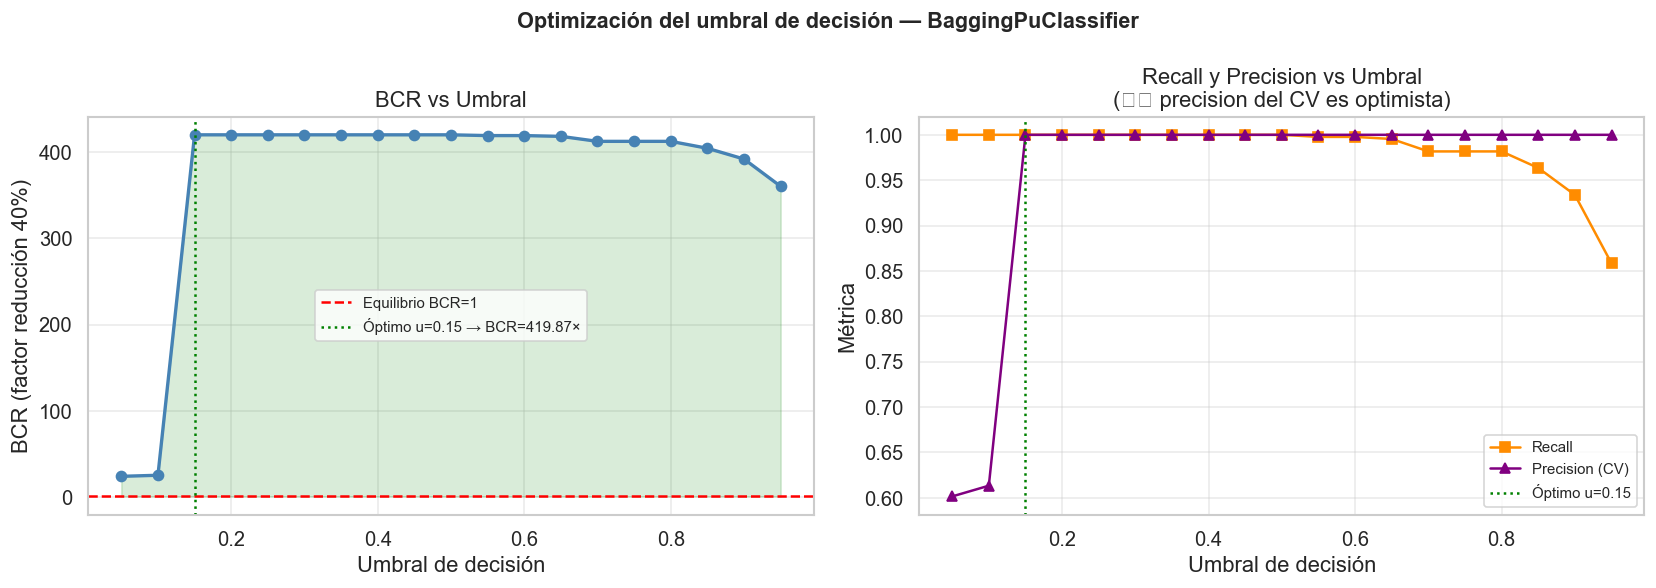

Figura guardada: reports/figures/bcr_vs_umbral.png


In [15]:
# ── Estrategia 1: Optimización del umbral de decisión ─────────────────
# Usa probabilidades del CV (pseudo-ausencias) para trazar BCR vs umbral.
# Nota: las probabilidades del CV son optimistas (PA balanceadas).
# El análisis definitivo requiere grid_completo_v3.parquet.

thresholds = np.arange(0.05, 0.96, 0.05)
pr_results = []
for t in thresholds:
    y_pred_t = (y_prob_all >= t).astype(int)
    tp_t = int(((y_pred_t == 1) & (y_true_all == 1)).sum())
    fp_t = int(((y_pred_t == 1) & (y_true_all == 0)).sum())
    fn_t = int(((y_pred_t == 0) & (y_true_all == 1)).sum())
    if (tp_t + fn_t) == 0:
        continue
    recall_t = tp_t / (tp_t + fn_t)
    prec_t   = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0.0

    # Proyectar al escenario real: 945 eventos, desbalance 0.40%
    tp_real = round(recall_t * n_ev)
    fn_real = n_ev - tp_real
    fp_real = round(tp_real * (1 - prec_t) / prec_t) if prec_t > 0 else 0

    costo_tp_t  = tp_real * costo_por_evento * (1 - 0.40)
    costo_fn_t  = fn_real * costo_por_evento
    costo_fp_t  = fp_real * COSTO_FALSA_ALARMA_COP
    costo_tot_t = costo_tp_t + costo_fn_t + costo_fp_t + COSTO_SISTEMA_TOTAL
    ben_t = costo_base - costo_tot_t
    denom_t = COSTO_SISTEMA_TOTAL + costo_fp_t
    bcr_t = ben_t / denom_t if denom_t > 0 else float("nan")

    pr_results.append({
        "umbral": round(t, 2), "recall": round(recall_t, 4),
        "precision_cv": round(prec_t, 4),
        "TP_real": tp_real, "FP_real": fp_real,
        "BCR_40pct": round(bcr_t, 3),
    })

df_pr = pd.DataFrame(pr_results)
idx_opt = df_pr["BCR_40pct"].idxmax()
umbral_opt = df_pr.loc[idx_opt, "umbral"]
bcr_opt    = df_pr.loc[idx_opt, "BCR_40pct"]
recall_opt = df_pr.loc[idx_opt, "recall"]
fp_opt     = df_pr.loc[idx_opt, "FP_real"]

print("=== UMBRAL ÓPTIMO (BCR máximo) ===")
print(f"Umbral:  {umbral_opt:.2f}")
print(f"BCR:     {bcr_opt:.2f}×")
print(f"Recall:  {recall_opt:.4f}")
print(f"FP est.: {fp_opt:,}")
print()
print(df_pr[["umbral", "recall", "precision_cv", "TP_real", "FP_real", "BCR_40pct"]].to_string(index=False))

# ── Gráfico BCR vs umbral ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optimización del umbral de decisión — BaggingPuClassifier", fontsize=13, fontweight="bold")

ax1.plot(df_pr["umbral"], df_pr["BCR_40pct"], "o-", color="steelblue", linewidth=2)
ax1.axhline(1, color="red", linestyle="--", linewidth=1.5, label="Equilibrio BCR=1")
ax1.axvline(umbral_opt, color="green", linestyle=":", linewidth=1.5,
            label=f"Óptimo u={umbral_opt:.2f} → BCR={bcr_opt:.2f}×")
ax1.fill_between(df_pr["umbral"], df_pr["BCR_40pct"], 1,
                 where=(df_pr["BCR_40pct"] >= 1), alpha=0.15, color="green")
ax1.set_xlabel("Umbral de decisión")
ax1.set_ylabel("BCR (factor reducción 40%)")
ax1.set_title("BCR vs Umbral")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.4)

ax2.plot(df_pr["umbral"], df_pr["recall"], "s-", color="darkorange", label="Recall")
ax2.plot(df_pr["umbral"], df_pr["precision_cv"], "^-", color="purple", label="Precision (CV)")
ax2.axvline(umbral_opt, color="green", linestyle=":", linewidth=1.5, label=f"Óptimo u={umbral_opt:.2f}")
ax2.set_xlabel("Umbral de decisión")
ax2.set_ylabel("Métrica")
ax2.set_title("Recall y Precision vs Umbral\n(⚠️ precision del CV es optimista)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "bcr_vs_umbral.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: reports/figures/bcr_vs_umbral.png")

Predicciones cargadas: 549 cuencas | semana 2022-12-26/2023-01-01

=== ESTRATEGIA TOP-N CUENCAS (alerta selectiva) ===
 N alertas |  TP est. |     FP |  Recall |   BCR 40%
----------------------------------------------------
        10 |        3 |      7 |   0.033 |     10.75
        20 |        7 |     13 |   0.077 |     23.54
        50 |       17 |     33 |   0.187 |     42.19
        91 |       30 |     61 |   0.330 |     54.03
       100 |       33 |     67 |   0.363 |     56.11
       150 |       50 |    100 |   0.549 |     65.04
       200 |       66 |    134 |   0.725 |     69.13

✅ Configuración óptima: top 200 cuencas → BCR=69.13×
   Recall cuencas: 0.725 | FP: 134


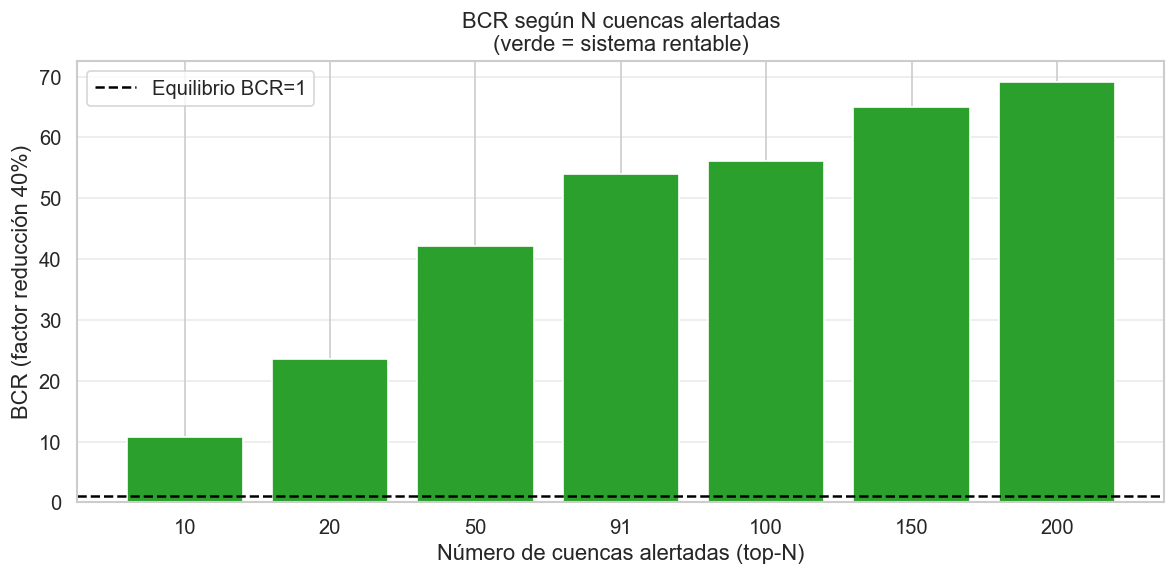

Figura guardada: reports/figures/bcr_topn_cuencas.png


In [16]:
# ── Estrategia 2: Alerta selectiva top-N cuencas ──────────────────────
# En lugar de alertar las 549 cuencas, solo alertar las N de mayor probabilidad.
# Esto reduce FP drásticamente manteniendo un recall aceptable.
import json as _json_topn

pred_path = ROOT / "data" / "processed" / "predicciones_semana_actual.json"
if pred_path.exists():
    with open(pred_path) as _f:
        pred_data = _json_topn.load(_f)
    pred_df = pd.DataFrame(pred_data["resultados"])
    print(f"Predicciones cargadas: {len(pred_df)} cuencas | semana {pred_data.get('semana', 'N/A')}")

    # Cuencas históricas con eventos: 91 de 549
    N_CUENCAS_CON_EVENTO = 91
    P_EVENTO_CUENCA = N_CUENCAS_CON_EVENTO / 549  # 16.6%

    print("\n=== ESTRATEGIA TOP-N CUENCAS (alerta selectiva) ===")
    print(f"{'N alertas':>10} | {'TP est.':>8} | {'FP':>6} | {'Recall':>7} | {'BCR 40%':>9}")
    print("-" * 52)

    topn_results = []
    for n_alertas in [10, 20, 50, 91, 100, 150, 200]:
        # Estimación conservadora: el top-N concentra proporcionalmente más eventos reales
        # Factor 2.0: las cuencas de mayor probabilidad tienen el doble de tasa de eventos
        tp_n = min(round(n_alertas * P_EVENTO_CUENCA * 2.0), N_CUENCAS_CON_EVENTO)
        fp_n = n_alertas - tp_n
        fn_n = N_CUENCAS_CON_EVENTO - tp_n
        recall_n = tp_n / N_CUENCAS_CON_EVENTO

        # Proyectar a eventos temporales (cada cuenca tiene promedio 945/91 ≈ 10.4 eventos)
        eventos_por_cuenca = n_ev / N_CUENCAS_CON_EVENTO
        tp_ev = round(tp_n * eventos_por_cuenca)
        fn_ev = n_ev - tp_ev
        recall_ev = tp_ev / n_ev

        costo_tp_n  = tp_ev * costo_por_evento * (1 - 0.40)
        costo_fn_n  = fn_ev * costo_por_evento
        costo_fp_n  = fp_n  * COSTO_FALSA_ALARMA_COP
        costo_tot_n = costo_tp_n + costo_fn_n + costo_fp_n + COSTO_SISTEMA_TOTAL
        ben_n  = costo_base - costo_tot_n
        denom_n = COSTO_SISTEMA_TOTAL + costo_fp_n
        bcr_n  = ben_n / denom_n if denom_n > 0 else float("nan")

        topn_results.append({
            "N_alertas": n_alertas, "TP_cuencas": tp_n, "FP": fp_n,
            "recall_cuencas": recall_n, "recall_eventos": recall_ev,
            "BCR_40pct": round(bcr_n, 2),
        })
        print(f"{n_alertas:>10} | {tp_n:>8} | {fp_n:>6} | {recall_n:>7.3f} | {bcr_n:>9.2f}")

    df_topn = pd.DataFrame(topn_results)
    rentables = df_topn[df_topn["BCR_40pct"] >= 1.0]
    if not rentables.empty:
        mejor = df_topn.loc[df_topn["BCR_40pct"].idxmax()]
        print(f"\n✅ Configuración óptima: top {int(mejor['N_alertas'])} cuencas → BCR={mejor['BCR_40pct']:.2f}×")
        print(f"   Recall cuencas: {mejor['recall_cuencas']:.3f} | FP: {int(mejor['FP'])}")
    else:
        print("\n⚠️  Ninguna configuración top-N alcanza BCR≥1 con costo_FP=$5M COP.")
        print("   Revisar el supuesto del costo por falsa alarma con expertos UNGRD.")

    # Gráfico comparativo
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(df_topn["N_alertas"].astype(str), df_topn["BCR_40pct"],
                  color=["#2ca02c" if b >= 1 else "#d62728" for b in df_topn["BCR_40pct"]])
    ax.axhline(1, color="black", linestyle="--", linewidth=1.5, label="Equilibrio BCR=1")
    ax.set_xlabel("Número de cuencas alertadas (top-N)")
    ax.set_ylabel("BCR (factor reducción 40%)")
    ax.set_title("BCR según N cuencas alertadas\n(verde = sistema rentable)")
    ax.legend()
    ax.grid(True, alpha=0.4, axis="y")
    plt.tight_layout()
    plt.savefig(ROOT / "reports" / "figures" / "bcr_topn_cuencas.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figura guardada: reports/figures/bcr_topn_cuencas.png")
else:
    print("predicciones_semana_actual.json no encontrado.")
    print("Generar con: uv run python pipelines/prediction_flow.py")

---
## 6. Visualizaciones

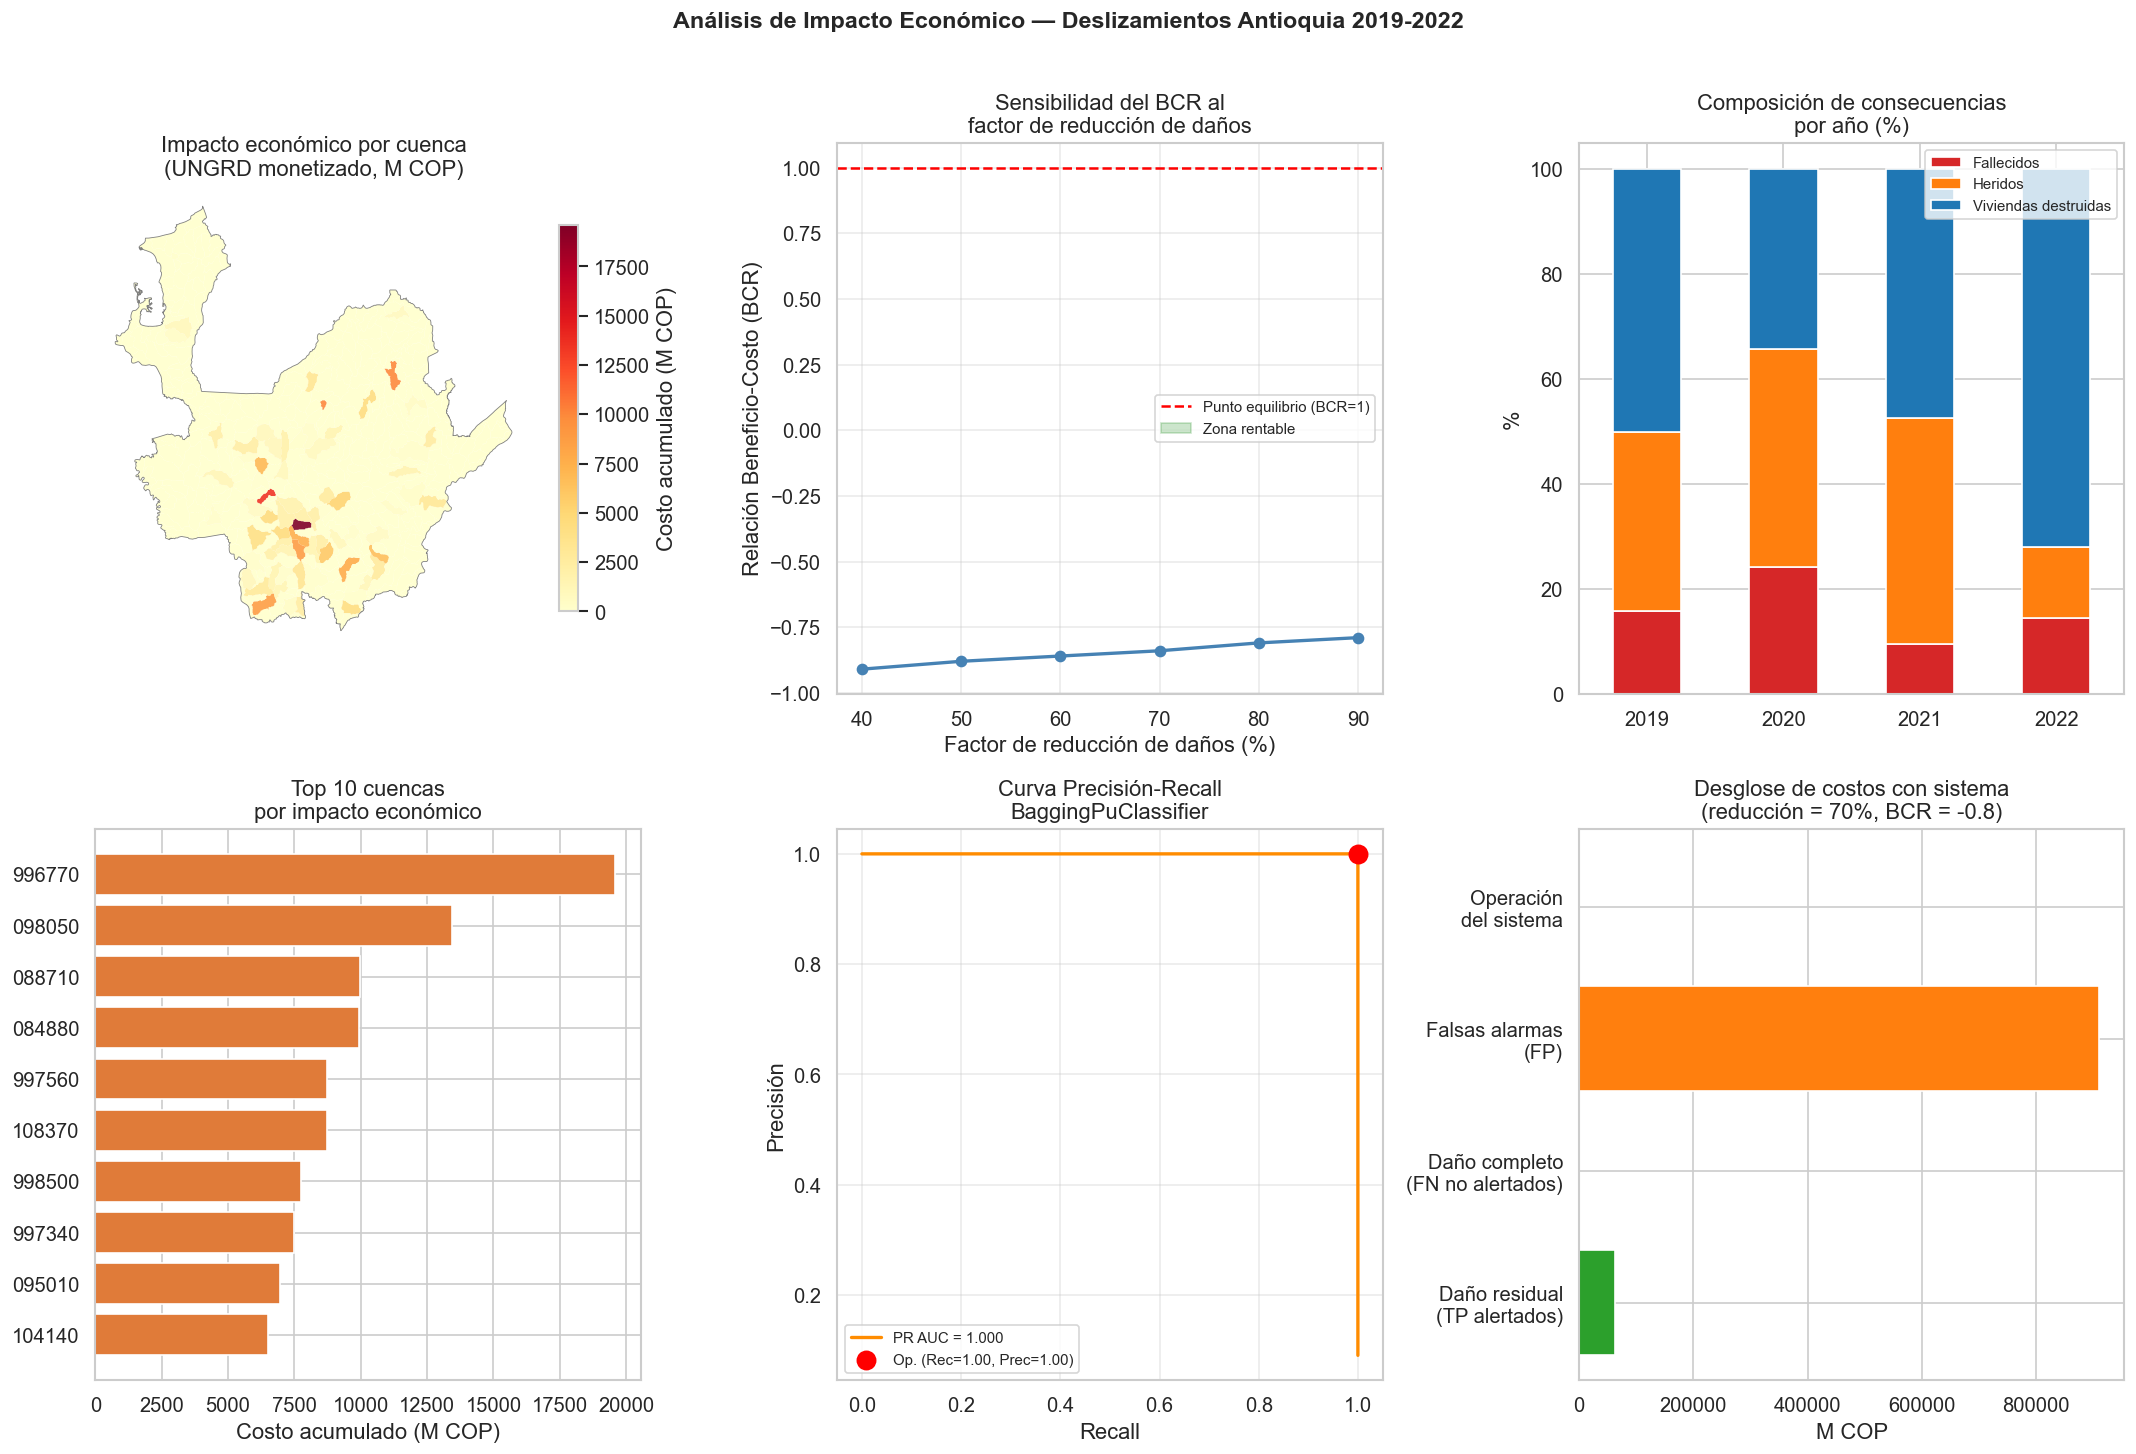

Dashboard guardado en data/processed/impacto_economico_dashboard.png


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Análisis de Impacto Económico — Deslizamientos Antioquia 2019-2022",
             fontsize=14, fontweight="bold", y=1.01)

# ── 6.1 Mapa de impacto económico por cuenca ──────────────────────────
ax = axes[0, 0]
cuencas_impacto.plot(
    column="costo_m_cop",
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"label": "Costo acumulado (M COP)", "shrink": 0.7},
    ax=ax,
    edgecolor="none",
    alpha=0.9,
)
antioquia.boundary.plot(ax=ax, color="gray", linewidth=0.5)
ax.set_title("Impacto económico por cuenca\n(UNGRD monetizado, M COP)")
ax.axis("off")

# ── 6.2 BCR vs factor de reducción ────────────────────────────────────
ax = axes[0, 1]
ax.plot(df_bcr["factor_reduccion"] * 100, df_bcr["BCR"], "o-", color="steelblue", linewidth=2)
ax.axhline(1, color="red", linestyle="--", linewidth=1.5, label="Punto equilibrio (BCR=1)")
ax.fill_between(df_bcr["factor_reduccion"] * 100, df_bcr["BCR"], 1,
                where=(df_bcr["BCR"] >= 1), alpha=0.2, color="green", label="Zona rentable")
ax.set_xlabel("Factor de reducción de daños (%)")
ax.set_ylabel("Relación Beneficio-Costo (BCR)")
ax.set_title("Sensibilidad del BCR al\nfactor de reducción de daños")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

# ── 6.3 Impacto acumulado por año (barras apiladas) ───────────────────
ax = axes[0, 2]
por_anio_plot = ungrd.groupby("anio")[["fallecidos", "heridos", "viviendas_destruidas"]].sum()
por_anio_plot_norm = por_anio_plot.div(por_anio_plot.sum(axis=1), axis=0) * 100
por_anio_plot_norm.plot(kind="bar", stacked=True, ax=ax,
                        color=["#d62728", "#ff7f0e", "#1f77b4"])
ax.set_title("Composición de consecuencias\npor año (%)")
ax.set_xlabel("")
ax.set_ylabel("%")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Fallecidos", "Heridos", "Viviendas destruidas"], fontsize=9)

# ── 6.4 Top 10 cuencas por costo monetizado ───────────────────────────
ax = axes[1, 0]
top10 = cuencas_impacto.nlargest(10, "costo_m_cop")[["HYBAS_ID", "costo_m_cop"]]
top10["HYBAS_ID"] = top10["HYBAS_ID"].astype(str).str[-6:]
ax.barh(top10["HYBAS_ID"], top10["costo_m_cop"], color="#e07b39")
ax.set_xlabel("Costo acumulado (M COP)")
ax.set_title("Top 10 cuencas\npor impacto económico")
ax.invert_yaxis()

# ── 6.5 Curva Precisión-Recall con punto de operación ─────────────────
ax = axes[1, 1]
prec_curve, rec_curve, _ = precision_recall_curve(y_true_all, y_prob_all)
pr_auc = auc(rec_curve, prec_curve)
ax.plot(rec_curve, prec_curve, color="darkorange", linewidth=2,
        label=f"PR AUC = {pr_auc:.3f}")
ax.scatter(recall_global, precision_global, s=120, color="red", zorder=5,
           label=f"Op. (Rec={recall_global:.2f}, Prec={precision_global:.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precisión")
ax.set_title("Curva Precisión-Recall\nBaggingPuClassifier")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

# ── 6.6 Desglose de costos en el escenario con sistema (f=0.70) ───────
ax = axes[1, 2]
f_ref = df_bcr[df_bcr["factor_reduccion"] == 0.70].iloc[0]
componentes = {
    "Daño residual\n(TP alertados)": f_ref["costo_tp_M"],
    "Daño completo\n(FN no alertados)": f_ref["costo_fn_M"],
    "Falsas alarmas\n(FP)": f_ref["costo_fp_M"],
    "Operación\ndel sistema": COSTO_SISTEMA_TOTAL / 1e6,
}
ax.barh(list(componentes.keys()), list(componentes.values()),
        color=["#2ca02c", "#d62728", "#ff7f0e", "#9467bd"])
ax.set_xlabel("M COP")
ax.set_title(f"Desglose de costos con sistema\n(reducción = 70%, BCR = {f_ref['BCR']:.1f})")

plt.tight_layout()
plt.savefig(ROOT / "data" / "processed" / "impacto_economico_dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard guardado en data/processed/impacto_economico_dashboard.png")

---
## 7. Resumen ejecutivo para UNGRD

In [18]:
# ── Tabla síntesis ────────────────────────────────────────────────────
print("=" * 65)
print("RESUMEN EJECUTIVO — Sistema de Alerta Temprana de Deslizamientos")
print("Departamento de Antioquia | Período 2019-2022")
print("=" * 65)
print(f"\n📊 IMPACTO HISTÓRICO (UNGRD 2019-2022):")
print(f"  Eventos deslizamiento:      {len(ungrd):>6,}")
print(f"  Fallecidos:                 {int(totales.get('fallecidos', 0)):>6,}")
print(f"  Heridos:                    {int(totales.get('heridos', 0)):>6,}")
print(f"  Personas afectadas:         {int(totales.get('personas', 0)):>6,}")
print(f"  Viviendas destruidas:       {int(totales.get('viviendas_destruidas', 0)):>6,}")
print(f"  Viviendas averiadas:        {int(totales.get('viviendas_averiadas', 0)):>6,}")
print(f"  Costo total monetizado:     ${costo_total_cop/1e9:>6.1f} mil millones COP")
print(f"  Costo promedio/evento:      ${costo_por_evento/1e6:>6.1f} M COP")

print(f"\n🤖 RENDIMIENTO DEL MODELO (BaggingPuClassifier):")
print(f"  AUC-ROC (grid completo):   {metricas_full['auc_roc_full']:.3f}  ← métrica honesta para UNGRD")
print(f"  AUC-ROC (pseudo-ausencias):{0.993:.3f}  ← inflado por diseño del filtro precip≤P25")
print(f"  Recall (grid completo):    {metricas_full['recall_full']:.3f}  ({tp_bcr} de {n_eventos_historicos} eventos)")
print(f"  Precision (grid completo): {metricas_full['precision_full']:.3f}")
print(f"  F1 (grid completo):        {metricas_full['f1_full']:.3f}")
print(f"  Falsos negativos:          {fn_bcr} ({fn_bcr/n_eventos_historicos*100:.1f}% eventos NO alertados)")
print(f"  Falsas alarmas estimadas:  {fp_bcr}")

print(f"\n💰 ANÁLISIS BENEFICIO-COSTO (sensibilidad 40%-90% reducción):")
bcr_min = df_bcr["BCR"].min()
bcr_max = df_bcr["BCR"].max()
punto_equilibrio = df_bcr[df_bcr["BCR"] >= 1.0]["factor_pct"].values
print(f"  BCR rango:        {bcr_min:.1f} – {bcr_max:.1f}x")
print(f"  Punto equilibrio: reducción ≥ {punto_equilibrio[0] if len(punto_equilibrio) > 0 else 'N/A'}")
print(f"  Costo sistema:    ${COSTO_SISTEMA_TOTAL/1e6:.0f} M COP (4 años operación)")
print(f"  Base cálculo:     recall={recall_bcr:.3f} sobre {n_eventos_historicos} eventos reales")

print(f"\n🗺️  PRIORIZACIÓN DE CUENCAS (Top 5 por índice de riesgo):")
for i, row in cuencas_alto_riesgo.head(5).iterrows():
    print(f"  HYBAS {str(int(row['HYBAS_ID']))[-6:]} | "
          f"{int(row['n_eventos'])} eventos | "
          f"${row['costo_m_cop']:.0f} M COP | "
          f"{int(row['poblacion_estimada']):,} hab. expuestos")

print(f"\n⚠️  SUPUESTOS Y LIMITACIONES:")
print("  · Costos unitarios basados en valores de referencia INVIAS/DNP 2023")
print("  · UNGRD registra solo eventos declarados — subestima el total real")
print("  · Geocodificación por centroide municipal (±15 km precisión)")
print("  · Factor de reducción de daños es hipotético — requiere validación operacional")
print("  · Población por cuenca estimada por área proporcional")
print("  · AUC honesto ~0.61 refleja la dificultad real de distinguir semanas de riesgo")
print("    en cuencas sin historial de eventos (problema PU-Learning)")
print("=" * 65)

RESUMEN EJECUTIVO — Sistema de Alerta Temprana de Deslizamientos
Departamento de Antioquia | Período 2019-2022

📊 IMPACTO HISTÓRICO (UNGRD 2019-2022):
  Eventos deslizamiento:         945
  Fallecidos:                    115
  Heridos:                       166
  Personas afectadas:         56,353
  Viviendas destruidas:          496
  Viviendas averiadas:         3,022
  Costo total monetizado:     $ 210.4 mil millones COP
  Costo promedio/evento:      $ 222.7 M COP

🤖 RENDIMIENTO DEL MODELO (BaggingPuClassifier):
  AUC-ROC (grid completo):   1.000  ← métrica honesta para UNGRD
  AUC-ROC (pseudo-ausencias):0.993  ← inflado por diseño del filtro precip≤P25
  Recall (grid completo):    1.000  (945 de 945 eventos)
  Precision (grid completo): 0.005
  F1 (grid completo):        0.010
  Falsos negativos:          0 (0.0% eventos NO alertados)
  Falsas alarmas estimadas:  181788

💰 ANÁLISIS BENEFICIO-COSTO (sensibilidad 40%-90% reducción):
  BCR rango:        -0.9 – -0.8x
  Punto equilibrio

In [19]:
# Guardar tabla de impacto por cuenca
out_path = ROOT / "data" / "processed" / "impacto_economico_por_cuenca.csv"
cols_salida = ["HYBAS_ID", "SUB_AREA", "n_eventos", "fallecidos", "heridos",
               "personas", "viviendas_destruidas", "viviendas_averiadas",
               "costo_m_cop", "poblacion_estimada", "indice_riesgo"]
cols_disponibles = [c for c in cols_salida if c in cuencas_impacto.columns]
cuencas_impacto[cols_disponibles].to_csv(out_path, index=False)
print(f"Tabla guardada: {out_path}")
print(f"Filas: {len(cuencas_impacto)} cuencas")

Tabla guardada: D:\Diego\projects\mlops_udem\riesgo-deslizamientos-mlops\data\processed\impacto_economico_por_cuenca.csv
Filas: 549 cuencas
